In [91]:
# Zachary Katz
# zachary_katz@mines.edu
# 14 April 2025

"""
Figure 1 Whillans Catalog Paper

v2.0 15 June 2025
 - Revamped GMT code to Matplotlib; Added axes labels
"""


# Imports and Extensions

import numpy as np
import xarray as xr
import shapefile
import shapely
import h5py
from cmap import Colormap
import rasterio
import pandas as pd

# Plotting
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import cartopy.crs as ccrs

import matplotlib.ticker as ticker

#############################
## User-Defined Parameters ##
gl_path = "/mnt/c/Users/ZacharyKatz/Desktop/Research/Background/Antarctica_masks/scripps_antarctica_polygons_v1.shp"  # Path to Grounding Line
vel_path = "/mnt/c/users/ZacharyKatz/Desktop/Research/Background/Measures_v2/antarctica_ice_velocity_450m_v2.nc"  # Path to velocity field
moa_path = "/mnt/c/Users/ZacharyKatz/Desktop/Research/Background/moa750_2009_hp1_v1.1.tif"  # Path to MOA
lakes_path = "/mnt/c/Users/ZacharyKatz/Desktop/Research/Background//SiegfriedFricker2018-outlines.h5"  # Path to lakes
## User-Defined Parameters ##
#############################

In [7]:
def plot_shapefile(
    records: list[shapefile._Record],
    shapes: list[shapefile.Shape],
    ax,
    colors: list[str],
    transform,
    fill: bool = False,
) -> None:
    """
    Plots the given records and shapes on axis ax.

    Parameters
    ----------
    records : list[shapefile._Record]
        Shapely record containing shape classification
    shapes : list[shapefile.Shape]
        Shapely shape points
    ax : cartopy.mpl.geoaxes.GeoAxes
        Axes to polot on
    colors : list[str]
       [Grounded ice color, Ice Shelf color]; Must be length 2
    """
    for record, shape in zip(records, shapes):
        classification = record[field_names.index("Id_text")]
        points = shape.points
        parts = list(shape.parts)
        parts.append(
            len(points)
        )  # Append the end index of the last part of the shapefile
        for i in range(len(parts) - 1):
            part = points[parts[i] : parts[i + 1]]
            if (
                classification == "Isolated island"
                or classification == "Ice rise or connected island"
                or classification == "Grounded ice or land"
            ):
                if fill:
                    ax.fill(*zip(*part), color=colors[0], zorder=2, transform=transform)
                else:
                    ax.plot(
                        *zip(*part),
                        color=colors[0],
                        linewidth=1.5,
                        zorder=2,
                        transform=transform,
                    )
            elif classification == "Ice shelf":
                if fill:
                    ax.fill(*zip(*part), color=colors[1], zorder=2, transform=transform)
                else:
                    ax.plot(
                        *zip(*part),
                        color=colors[1],
                        linewidth=1.5,
                        zorder=2,
                        transform=transform,
                    )
            else:
                print(f"Unknown classification: {classification}")

In [9]:
ice_shelf_polygons = []
grounded_polygons = []

sf = shapefile.Reader(gl_path)
fields = sf.fields[1:]  # Skip deletion flag
field_names = [field[0] for field in fields]

records = sf.records()
shapes = sf.shapes()

for record, shape in zip(records, shapes):
    classification = record[field_names.index("Id_text")]
    points = shape.points
    parts = list(shape.parts)
    parts.append(len(points))  # Append the end index of the last part
    for i in range(len(parts) - 1):
        part = points[parts[i] : parts[i + 1]]
        polygon = shapely.Polygon(part)
        if (
            classification == "Isolated island"
            or classification == "Ice rise or connected island"
            or classification == "Grounded ice or land"
        ):
            if polygon.is_valid:
                grounded_polygons.append(polygon)
        elif classification == "Ice shelf":
            if polygon.is_valid:
                ice_shelf_polygons.append(polygon)
        else:
            print(f"Unknown classification: {classification}")

In [130]:
# Plot stations [Adpated from Figure1.sh]
out = "Figure1"  # Output file name

xl = -310000
yl = -621000
xh = -140000
yh = -490000

bbox = [xl, yl, xh, yh]  # Bounding box for the figure

mxl = -185000
myl = -618000
mxh = -152000
myh = -580000

inset_bbox = [mxl, myl, mxh, myh]  # Bounding box for the inset

In [16]:
# Load velocity
off = 10000
oslo = Colormap("crameri:oslo").to_matplotlib()
vel = xr.open_dataset(vel_path)
cropped_vel = vel.sel(
    x=slice(bbox[0] - off, bbox[2] + off), y=slice(bbox[3] + off, bbox[1] - off)
)
vel_mag_sliced = np.sqrt(cropped_vel.VX**2 + cropped_vel.VY**2)

oslo = Colormap("crameri:oslo").to_matplotlib()

# Load Mosaic of Antarctica
with rasterio.open(moa_path) as moa:
    bounds = moa.bounds
    left, bottom, right, top = bounds.left, bounds.bottom, bounds.right, bounds.top
    moa_dat = moa.read(1)

ext = (left, right, bottom, top)

In [127]:
def sta_labels(row, ax, ps71_projection):
    if row["Justification"] == "TL":
        ha = "left"
        va = "bottom"
        adjust = 1500
    elif row["Justification"] == "TR":
        ha = "right"
        va = "bottom"
        adjust = 1500
    elif row["Justification"] == "BL":
        ha = "left"
        va = "top"
        adjust = -1500
    elif row["Justification"] == "BR":
        ha = "right"
        va = "top"
        adjust = -1500
    ax.text(
        row["X"],
        row["Y"] + adjust,
        row["Station"],
        fontsize=18,
        color="white",
        ha=ha,
        va=va,
        zorder=7,
        transform=ps71_projection,
        fontweight="bold",
    )

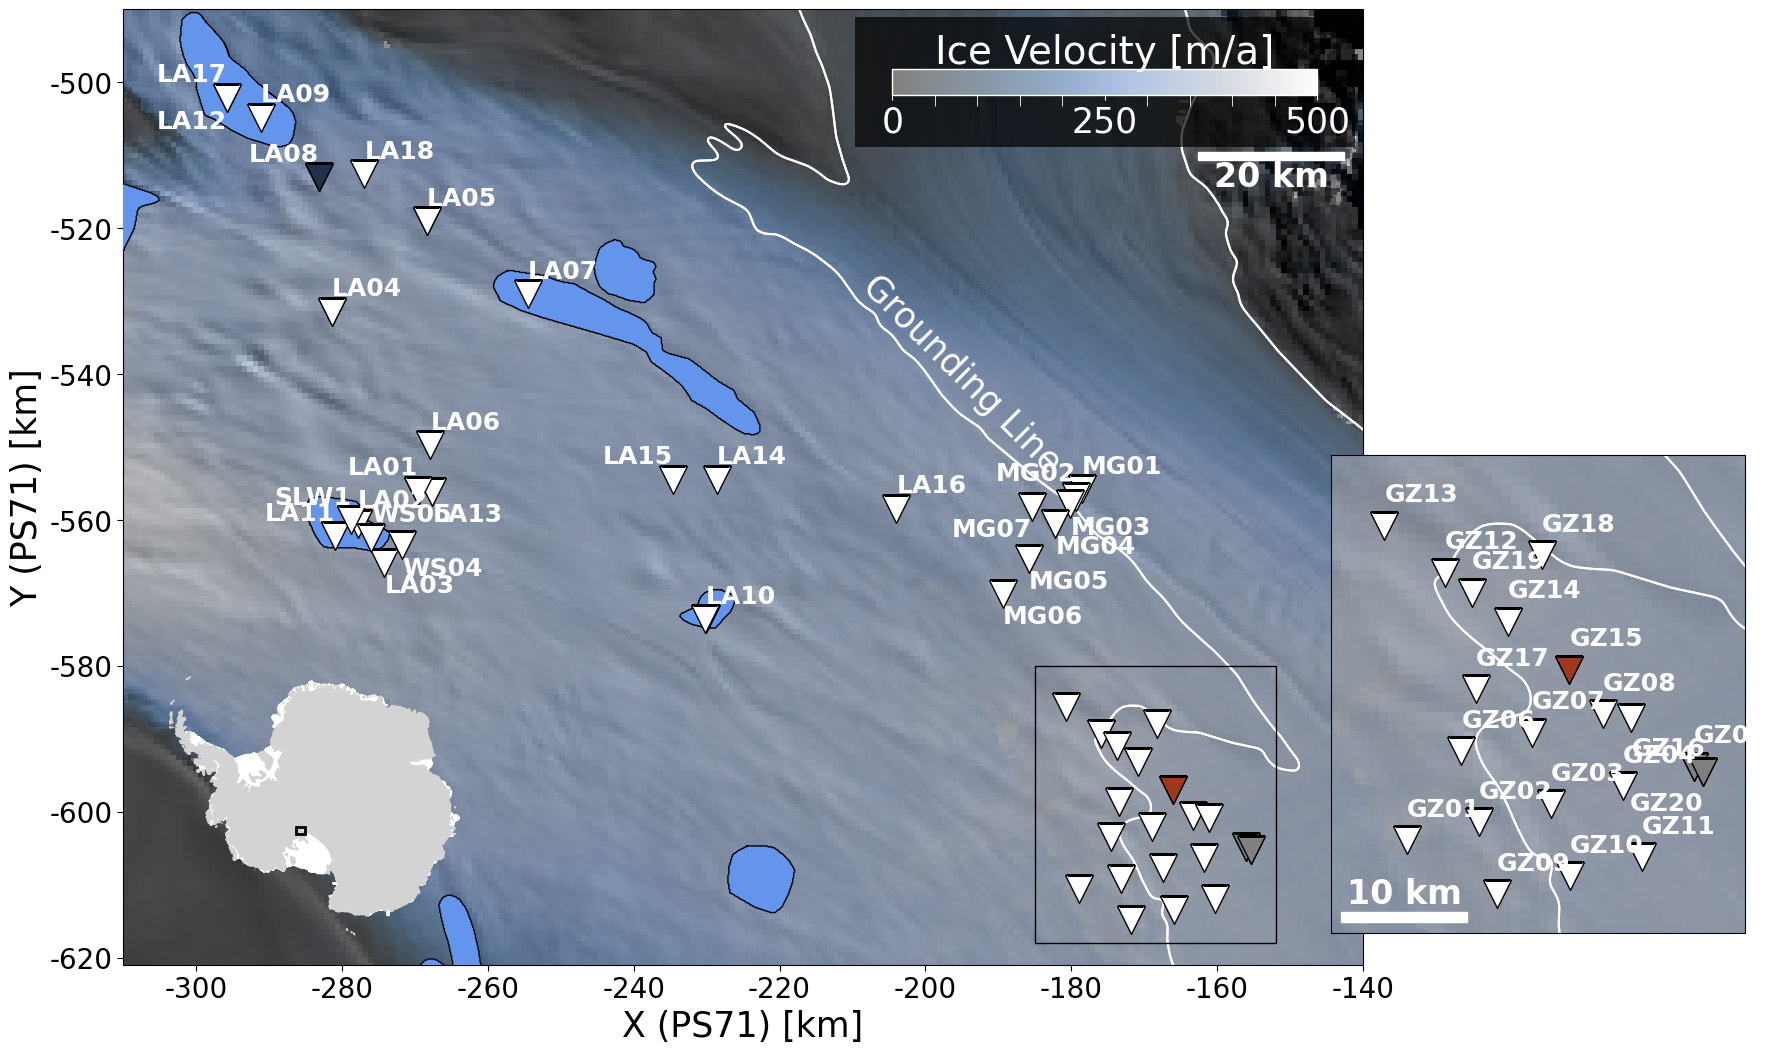

In [166]:
# PLOT
ps71_projection = ccrs.Stereographic(
    central_latitude=-90, central_longitude=0, true_scale_latitude=-71
)
fig, ax = plt.subplots(subplot_kw={"projection": ps71_projection}, figsize=(16, 16))


# MOA and Ice Velocity
ax.imshow(moa_dat, extent=ext, cmap="gray", vmin=15000, vmax=17000)
cb = ax.imshow(
    vel_mag_sliced,
    cmap=oslo,
    extent=[
        vel_mag_sliced["x"].min(),
        vel_mag_sliced["x"].max(),
        vel_mag_sliced["y"].min(),
        vel_mag_sliced["y"].max(),
    ],
    origin="upper",
    alpha=0.5,
    vmin=0,
    vmax=500,
)

# Lakes
with h5py.File(lakes_path, "r") as f:
    for group_name in f:
        if not isinstance(f[group_name], h5py.Group):
            continue

        x = f[f"{group_name}/x"][:].flatten()
        y = f[f"{group_name}/y"][:].flatten()
        if group_name == "Lake78":
            isnan = np.isnan(x) | np.isnan(y)
            split_indices = np.where(isnan)[0]
            x1 = x[: split_indices[0]]
            y1 = y[: split_indices[0]]
            x2 = x[split_indices[0] + 1 :]
            y2 = y[split_indices[0] + 1 :]
            ax.plot(x1, y1, color="black", linewidth=1, zorder=4)
            ax.fill(x1, y1, color="cornflowerblue", zorder=3)
            ax.plot(x2, y2, color="black", linewidth=1, zorder=4)
            ax.fill(x2, y2, color="cornflowerblue", zorder=3)
        else:
            ax.plot(x, y, color="black", linewidth=1, zorder=4)
            ax.fill(x, y, color="cornflowerblue", zorder=3)

# Grounding Line
plot_shapefile(records, shapes, ax, ["white", "white"], ps71_projection, fill=False)
# Grounding Line text next to the grounding line, tilted 45 degrees
ax.text(
    -195000,
    -540000,
    "Grounding Line",
    fontsize=25,
    color="white",
    ha="center",
    va="center",
    zorder=5,
    transform=ps71_projection,
    rotation=-45,
)
ax.set_xlim(xl, xh)
ax.set_ylim(yl, yh)

# Plot stations
stations = "Stations.txt"  # Station file name
stationsTop = "StationsTop.txt"
stationsBottom = "StationsBottom.txt"
stationsGZTop = "StationsGZTop.txt"
stationsGZBottom = "StationsGZBottom.txt"
stationsGZ15 = "GZ15.txt"
stationsLA08 = "LA08.txt"
stationsGZ05_GZ20 = "GZ05_GZ20.txt"

stations = pd.read_csv(stations, sep=" ")
stationsTop = pd.read_csv(stationsTop, sep=" ")
stationsBottom = pd.read_csv(stationsBottom, sep=" ")
stationsGZTop = pd.read_csv(stationsGZTop, sep=" ")
stationsGZBottom = pd.read_csv(stationsGZBottom, sep=" ")
stationsGZ15 = pd.read_csv(stationsGZ15, sep=" ")
stationsLA08 = pd.read_csv(stationsLA08, sep=" ")
stationsGZ05_GZ20 = pd.read_csv(stationsGZ05_GZ20, sep=" ")
sta_size = 400
ax.scatter(
    stations["X"],
    stations["Y"],
    marker="v",
    color="white",
    edgecolor="black",
    s=sta_size,
    zorder=6,
    transform=ps71_projection,
)
ax.scatter(
    stationsGZ15["X"],
    stationsGZ15["Y"],
    marker="v",
    color="#a03820",
    edgecolor="black",
    s=sta_size,
    zorder=6,
    transform=ps71_projection,
)
ax.scatter(
    stationsGZ05_GZ20["X"],
    stationsGZ05_GZ20["Y"],
    marker="v",
    color="#808080",
    edgecolor="black",
    s=sta_size,
    zorder=6,
    transform=ps71_projection,
)
ax.scatter(
    stationsLA08["X"],
    stationsLA08["Y"],
    marker="v",
    color="#21314D",
    edgecolor="black",
    s=sta_size,
    zorder=6,
    transform=ps71_projection,
)

for i, row in stationsTop.iterrows():
    sta_labels(row, ax, ps71_projection)
for i, row in stationsBottom.iterrows():
    sta_labels(row, ax, ps71_projection)


# Inset Map

bbox_0 = ax.get_position()
inset_x = bbox_0.x0
inset_y = bbox_0.y0
inset = fig.add_axes(
    [inset_x + 0.02, inset_y, bbox_0.height / 3, bbox_0.height / 3],
    projection=ps71_projection,
)  # [left, bottom, width, height]
inset.patch.set_facecolor("none")
for spine in inset.spines.values():
    spine.set_visible(False)
inset.set_xticks([])
inset.set_yticks([])

plot_shapefile(
    records, shapes, inset, ["lightgray", "white"], ps71_projection, fill=True
)
rect = plt.Rectangle(
    (
        bbox[0],
        bbox[1],
    ),
    bbox[2] - bbox[0],
    bbox[3] - bbox[1],
    zorder=3,
    linewidth=2,
    edgecolor="black",
    facecolor="none",
)
inset.add_patch(rect)

rxl = -760000
ryl = -1400000
rxh = 600000
ryh = -350000
# inset.set_xlim(rxl,rxh)
# inset.set_ylim(ryl,ryh)


v_cbar_anchor = (0.999, 0.999)
cbbox = inset_axes(
    ax,
    width=5,
    height=1.3,
    bbox_to_anchor=v_cbar_anchor,
    bbox_transform=ax.transAxes,
    loc="upper right",
)
[cbbox.spines[k].set_visible(False) for k in cbbox.spines]
cbbox.tick_params(
    axis="both",
    left=False,
    top=False,
    right=False,
    bottom=False,
    labelleft=False,
    labeltop=False,
    labelright=False,
    labelbottom=False,
)
cbbox.set_facecolor([0, 0, 0, 0.7])

cbaxes = inset_axes(cbbox, "85%", "20%", loc="center")
cbar = fig.colorbar(cb, cax=cbaxes, orientation="horizontal")  # make colorbar
cbar.outline.set_edgecolor("white")
cbar.outline.set_linewidth(1)
cbar.ax.tick_params(labelsize=25, color="white", labelcolor="white")
cbar.set_label("Ice Velocity [m/a]", fontsize=28, color="white")
cbar.ax.xaxis.set_label_position("top")

cbar.ax.minorticks_on()

cbar.ax.tick_params(which="minor", length=8, color="white")
cbar.ax.xaxis.set_major_locator(ticker.MultipleLocator(250))

# Scale Bar
scalebar = AnchoredSizeBar(
    ax.transData,
    20000,
    "20 km",
    "lower right",
    pad=0.1,
    sep=1,
    color="white",
    frameon=False,
    size_vertical=1000,
    fontproperties=mpl.font_manager.FontProperties(size=24, weight="bold"),
    label_top=False,
)
ax.add_artist(scalebar)
bbox_0 = ax.get_position()
scalebar.set_bbox_to_anchor((0.99, 0.8), transform=ax.transAxes)

# Inset for GZ
bbox_0 = ax.get_position()
inset_x = bbox_0.x1
inset_y = bbox_0.y0
inset = fig.add_axes(
    [inset_x - 0.04, inset_y + 0.02, bbox_0.height / 2, bbox_0.height / 2],
    projection=ps71_projection,
)  # [left, bottom, width, height]

inset.imshow(moa_dat, extent=ext, cmap="gray", vmin=15000, vmax=17000)
cb = inset.imshow(
    vel_mag_sliced,
    cmap=oslo,
    extent=[
        vel_mag_sliced["x"].min(),
        vel_mag_sliced["x"].max(),
        vel_mag_sliced["y"].min(),
        vel_mag_sliced["y"].max(),
    ],
    origin="upper",
    alpha=0.5,
    vmin=0,
    vmax=500,
)
plot_shapefile(records, shapes, inset, ["white", "white"], ps71_projection, fill=False)
inset.set_xlim(mxl, mxh)
inset.set_ylim(myl, myh)

inset.scatter(
    stations["X"],
    stations["Y"],
    marker="v",
    color="white",
    edgecolor="black",
    s=sta_size,
    zorder=6,
    transform=ps71_projection,
)
inset.scatter(
    stationsGZ15["X"],
    stationsGZ15["Y"],
    marker="v",
    color="#a03820",
    edgecolor="black",
    s=sta_size,
    zorder=6,
    transform=ps71_projection,
)
inset.scatter(
    stationsGZ05_GZ20["X"],
    stationsGZ05_GZ20["Y"],
    marker="v",
    color="#808080",
    edgecolor="black",
    s=sta_size,
    zorder=6,
    transform=ps71_projection,
)

for i, row in stationsGZTop.iterrows():
    sta_labels(row, inset, ps71_projection)
for i, row in stationsGZBottom.iterrows():
    sta_labels(row, inset, ps71_projection)

# And a box around the inset
rect = plt.Rectangle(
    (
        inset_bbox[0],
        inset_bbox[1],
    ),
    inset_bbox[2] - inset_bbox[0],
    inset_bbox[3] - inset_bbox[1],
    zorder=3,
    linewidth=1,
    edgecolor="black",
    facecolor="none",
)
ax.add_patch(rect)

scalebar = AnchoredSizeBar(
    inset.transData,
    10000,
    "10 km",
    "lower left",
    pad=0.1,
    sep=1,
    color="white",
    frameon=False,
    size_vertical=800,
    fontproperties=mpl.font_manager.FontProperties(size=24, weight="bold"),
    label_top=True,
)
inset.add_artist(scalebar)
scalebar.set_bbox_to_anchor((0.01, 0.01), transform=inset.transAxes)

KM_SCALE = 1e3
ax.xaxis.set_visible(True)
ax.yaxis.set_visible(True)
ticks_x = ticker.FuncFormatter(lambda x, pos: "{0:g}".format(x / KM_SCALE))
ax.xaxis.set_major_formatter(ticks_x)
ticks_y = ticker.FuncFormatter(lambda x, pos: "{0:g}".format(x / KM_SCALE))
ax.yaxis.set_major_formatter(ticks_y)
ax.set_xlabel("X (PS71) [km]", size=25)
ax.set_ylabel("Y (PS71) [km]", size=25)
ax.tick_params(labelsize=20)
ax.tick_params(size=4)